# Notebook 01 — Exploration et Nettoyage des données (EDA)

**Projet :** Analyse et Modélisation des Trajets des Taxis Jaunes de New York  
**Formation :** L3 DANT  
**Auteur :** Maissa  SACI

**Données :** Yellow Taxi Trip Records — Janvier 2026 (source : NYC TLC)

---

Ce notebook constitue la **première étape du projet** : la qualité des modèles développés aux étapes suivantes dépend directement de la rigueur du nettoyage effectué ici.

**Tickets couverts :**
- **T-02** — Chargement et exploration initiale des données
- **T-03** — Traitement des valeurs manquantes et des outliers
- **T-04** — Visualisations exploratoires

## 1.1 Chargement des données

### Source
Les données proviennent du programme **TPEP (Taxicab & Livery Passenger Enhancement Program)** de la NYC Taxi and Limousine Commission. Chaque ligne représente un trajet unique effectué par un taxi jaune.
### Échantillonnage
Le fichier complet de janvier 2026 contient plusieurs millions de lignes — trop lourd pour entraîner des modèles sur un poste standard. On travaille sur un **échantillon aléatoire de 100 000 lignes** avec `random_state=42` pour garantir la reproductibilité : chaque exécution produit exactement le même échantillon.

In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

df = pd.read_parquet('../data/yellow_tripdata.parquet')
print(f'Taille du fichier complet : {df.shape[0]:,} lignes x {df.shape[1]} colonnes')

df = df.sample(n=100_000, random_state=42).reset_index(drop=True)
print(f'Taille de l echantillon   : {df.shape[0]:,} lignes x {df.shape[1]} colonnes')
df.head()

Taille du fichier complet : 3,724,889 lignes x 20 colonnes
Taille de l echantillon   : 100,000 lignes x 20 colonnes


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2026-01-18 12:35:13,2026-01-18 12:46:05,1.0,3.90,1.0,N,68,238,1,17.00,3.25,0.5,2.50,0.00,1.0,24.25,2.5,0.0,0.75
1,2,2026-01-28 01:01:57,2026-01-28 01:34:45,NaN,13.95,NaN,None,69,61,0,49.13,0.00,0.5,0.00,7.46,1.0,58.09,NaN,NaN,0.00
2,2,2026-01-09 10:35:27,2026-01-09 11:05:50,1.0,13.79,1.0,N,13,138,1,55.50,5.00,0.5,19.57,0.00,1.0,84.82,2.5,0.0,0.75
3,2,2026-01-24 22:26:51,2026-01-24 22:37:03,1.0,1.76,1.0,N,164,79,2,11.40,1.00,0.5,0.00,0.00,1.0,17.15,2.5,0.0,0.75
4,2,2026-01-01 01:59:23,2026-01-01 02:13:41,NaN,7.42,NaN,None,74,232,0,41.06,0.00,0.5,0.00,0.00,1.0,45.81,NaN,NaN,0.75


## 1.2 Structure du jeu de données

Avant tout nettoyage, on examine la structure brute des données pour avoir une première vision d'ensemble.

- `df.info()` : types de chaque colonne et nombre de valeurs non-nulles — permet de repérer immédiatement les colonnes avec des valeurs manquantes
- `df.describe()` : statistiques descriptives (min, max, moyenne, quartiles) — c'est ici qu'on identifie les valeurs suspectes comme les montants négatifs ou les distances extrêmes

In [107]:
print('=== Types et completude des colonnes ===')
df.info()

=== Types et completude des colonnes ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               100000 non-null  int32         
 1   tpep_pickup_datetime   100000 non-null  datetime64[us]
 2   tpep_dropoff_datetime  100000 non-null  datetime64[us]
 3   passenger_count        70984 non-null   float64       
 4   trip_distance          100000 non-null  float64       
 5   RatecodeID             70984 non-null   float64       
 6   store_and_fwd_flag     70984 non-null   object        
 7   PULocationID           100000 non-null  int32         
 8   DOLocationID           100000 non-null  int32         
 9   payment_type           100000 non-null  int64         
 10  fare_amount            100000 non-null  float64       
 11  extra                  100000 non-null  float64       
 12  mta_

In [108]:
print('=== Statistiques descriptives ===')
df.describe().round(2)

=== Statistiques descriptives ===


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
count,100000.00,100000,100000,70984.00,100000.00,70984.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,70984.00,70984.00,100000.00
mean,1.87,2026-01-17 01:17:22.609380,2026-01-17 01:34:34.292840,1.26,5.57,5.28,161.20,161.01,0.85,20.67,1.03,0.48,2.59,0.49,0.95,29.00,2.15,0.15,0.52
min,1.00,2026-01-01 00:00:38,2026-01-01 00:04:08,0.00,0.00,1.00,1.00,1.00,0.00,-669.40,-7.50,-0.50,-50.00,-35.31,-1.00,-670.40,-2.50,-1.75,-0.75
25%,2.00,2026-01-09 17:37:58.750000,2026-01-09 17:55:10.500000,1.00,1.00,1.00,114.00,107.00,0.00,10.00,0.00,0.50,0.00,0.00,1.00,16.95,2.50,0.00,0.00
50%,2.00,2026-01-16 20:28:50.500000,2026-01-16 20:48:04,1.00,1.80,1.00,161.00,162.00,1.00,15.60,0.00,0.50,2.00,0.00,1.00,22.96,2.50,0.00,0.75
75%,2.00,2026-01-24 04:01:49.750000,2026-01-24 04:17:40.500000,1.00,3.70,1.00,233.00,234.00,1.00,25.95,2.50,0.50,3.70,0.00,1.00,33.60,2.50,0.00,0.75
max,7.00,2026-01-31 23:59:33,2026-02-01 00:36:25,6.00,121092.54,99.00,265.00,265.00,4.00,522.40,12.50,0.50,300.00,57.00,1.00,523.90,2.50,6.75,0.75
std,0.70,NaN,NaN,0.68,498.79,19.79,66.92,71.05,0.71,18.95,1.71,0.11,3.89,2.09,0.27,22.54,0.95,0.52,0.36


### Observations sur la structure

Le jeu de données contient **20 colonnes**, dont certaines absentes de la documentation officielle TLC (`cbd_congestion_fee`, `Airport_fee`). L'examen de `df.describe()` révèle plusieurs anomalies qui nécessitent un nettoyage :

**Sur les variables numériques :**
- `trip_distance` : min = 0 et **max = 121 092 miles** — erreur de capteur évidente 
- `fare_amount` / `total_amount` : **min négatifs** (-669 $ et -670 $) — des remboursements ou erreurs système enregistrés comme des courses
- `passenger_count` : min = 0 et **29 016 valeurs manquantes (29 %)** — champ saisi manuellement par le chauffeur, souvent omis

**Sur les variables catégorielles :**
- `payment_type` : contient une valeur **0**, non documentée par la TLC
- `RatecodeID` : **max = 99** alors que les codes valides vont de 1 à 6 — valeurs hors-normes à supprimer
- `tpep_dropoff_datetime` : certains dropoff tombent en **février 2026**, ce qui génèrerait des durées aberrantes

**Point d'attention :** `tip_amount` n'est renseigné que pour les paiements par carte (`payment_type = 1`). Les pourboires en espèces ne sont pas enregistrés — toute analyse des pourboires devra filtrer sur ce critère pour éviter un biais.

## 1.3 Valeurs manquantes

Nous quantifions les données manquantes colonne par colonne avant de décider de leur traitement.

**Stratégie générale adoptée :**
- **< 5 % de valeurs manquantes** : suppression directe des lignes concernées
  (pas d'imputation — le risque d'introduire du bruit dépasse le gain)
- **> 5 % de valeurs manquantes** : analyse au cas par cas selon l'importance
  de la variable pour la modélisation

                      Nb manquants  % manquants
passenger_count              29016        29.02
RatecodeID                   29016        29.02
store_and_fwd_flag           29016        29.02
congestion_surcharge         29016        29.02
Airport_fee                  29016        29.02


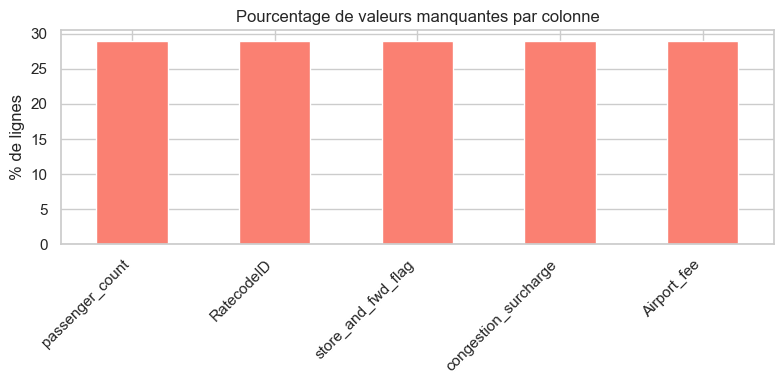

In [109]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Nb manquants': missing,
    '% manquants': missing_pct
})
missing_df = missing_df[missing_df['Nb manquants'] > 0].sort_values('Nb manquants', ascending=False)

if missing_df.empty:
    print('Aucune valeur manquante detectee dans l echantillon.')
else:
    print(missing_df)
    plt.figure(figsize=(8, 4))
    missing_df['% manquants'].plot(kind='bar', color='salmon', edgecolor='white')
    plt.title('Pourcentage de valeurs manquantes par colonne')
    plt.ylabel('% de lignes')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('../figures/01_missing_values.png', dpi=150)
    plt.show()

### Analyse et décision sur les valeurs manquantes

Le résultat de `df.isnull().sum()` ci-dessus montre un **bloc de 29 016 lignes manquantes**, soit **29 %** du dataset. .

Ces 29 016 lignes ont des NA sur exactement les mêmes colonnes (`passenger_count`, `RatecodeID`, `store_and_fwd_flag`, `congestion_surcharge`, `Airport_fee`), ce qui correspond très probablement à un **fournisseur spécifique** dont le système ne collecte pas ces champs.

- **`passenger_count`** (29 %) : indispensable pour la modélisation → les lignes NA seront exclues via le filtre outliers (NaN comparisons retournent False en pandas)
- **`RatecodeID`** (29 %) : non utilisée directement dans les modèles → conservée avec NA
- **`store_and_fwd_flag`** (29 %) : indicateur système, non utilisé → conservé tel quel
- **`congestion_surcharge`** et **`Airport_fee`** (29 %) : suppléments facultatifs selon zone → conservés avec NA

## 1.4 Détection et suppression des valeurs aberrantes

Le dataset contient des erreurs connues (compteurs bloqués, saisies manuelles incorrectes, oublis de fermeture). On applique les filtres un par un pour tracer l'impact de chacun.

In [110]:
df_clean = df.copy()
print(f'Lignes avant tout nettoyage : {len(df_clean):,}')

Lignes avant tout nettoyage : 100,000


### Filtre 1 — Distance (`trip_distance`)

- `trip_distance = 0` : course annulée ou compteur en panne, incompatible avec un trajet facturé
- `trip_distance >= 100 miles` : hors de la zone géographique desservie par les taxis jaunes NYC (le max observé est 121 092 miles — erreur de capteur évidente)

**Seuils retenus :** `0 < trip_distance < 100`

In [111]:
n_avant = len(df_clean)
df_clean = df_clean[(df_clean['trip_distance'] > 0) & (df_clean['trip_distance'] < 100)]
print(f'Apres filtre distance   : {len(df_clean):,} lignes  ({n_avant - len(df_clean):,} supprimees)')

Apres filtre distance   : 96,637 lignes  (3,363 supprimees)


### Filtre 2 — Durée du trajet

- Durée négative ou nulle : physiquement impossible 
- Durée > 180 min : oubli de fermeture de course, le compteur reste actif sans passager

**Seuils retenus :** `0 < durée_minutes <= 180`

In [112]:
n_avant = len(df_clean)
duree_temp = (
    pd.to_datetime(df_clean['tpep_dropoff_datetime']) -
    pd.to_datetime(df_clean['tpep_pickup_datetime'])
).dt.total_seconds() / 60

df_clean = df_clean[(duree_temp > 0) & (duree_temp <= 180)]
print(f'Apres filtre duree      : {len(df_clean):,} lignes  ({n_avant - len(df_clean):,} supprimees)')

Apres filtre duree      : 95,404 lignes  (1,233 supprimees)


### Filtre 3 — Montants (`fare_amount`, `total_amount`)

- Montant <= 0 : impossible pour une course facturée (min observé -669 $, probablement des annulations enregistrées par erreur)
- `fare_amount >= 500 $` : les courses les plus chères (aéroports) dépassent rarement 200 $ — au-delà c'est une erreur de saisie

**Seuils retenus :** `0 < fare_amount < 500` et `total_amount > 0`

In [113]:
n_avant = len(df_clean)
df_clean = df_clean[
    (df_clean['fare_amount'] > 0) & (df_clean['fare_amount'] < 500) &
    (df_clean['total_amount'] > 0)
]
print(f'Apres filtre montants   : {len(df_clean):,} lignes  ({n_avant - len(df_clean):,} supprimees)')

Apres filtre montants   : 94,371 lignes  (1,033 supprimees)


### Filtre 4 — Nombre de passagers (`passenger_count`)

- `passenger_count = 0` : saisie oubliée ou erreur, une course sans passager ne peut pas être facturée
- `passenger_count > 6` : capacité légale max d'un taxi jaune NYC = 6 passagers (réglementation TLC)
- Les NaN (29 016 lignes) sont exclus naturellement — NaN >= 1 retourne False en pandas

**Seuils retenus :** `1 <= passenger_count <= 6`

In [114]:
n_avant = len(df_clean)
df_clean = df_clean[
    (df_clean['passenger_count'] >= 1) & (df_clean['passenger_count'] <= 6)
]
print(f'Apres filtre passagers  : {len(df_clean):,} lignes  ({n_avant - len(df_clean):,} supprimees)')

Apres filtre passagers  : 67,440 lignes  (26,931 supprimees)


### Filtre 5 — RatecodeID et payment_type

- `RatecodeID` hors 1-6 : les codes TLC valides vont de 1 (standard) à 6 (groupe). Le max observé est 99 — valeur invalide à supprimer
- `payment_type = 0` : code non documenté par la TLC, probablement des erreurs d'enregistrement

In [115]:
n = len(df_clean)
df_clean = df_clean[df_clean['RatecodeID'].isin([1, 2, 3, 4, 5, 6])]
print(f'Filtre RatecodeID   : {n - len(df_clean):,} supprimees → {len(df_clean):,} restantes')

n = len(df_clean)
df_clean = df_clean[df_clean['payment_type'].isin([1, 2, 3, 4])]
print(f'Filtre payment_type : {n - len(df_clean):,} supprimees → {len(df_clean):,} restantes')

Filtre RatecodeID   : 2,988 supprimees → 64,452 restantes
Filtre payment_type : 0 supprimees → 64,452 restantes


In [116]:
lignes_init    = len(df)
lignes_finales = len(df_clean)
lignes_supprim = lignes_init - lignes_finales

print('=' * 50)
print('  BILAN DU NETTOYAGE')
print('=' * 50)
print(f'  Lignes initiales   : {lignes_init:>8,}')
print(f'  Lignes supprimees  : {lignes_supprim:>8,}  ({lignes_supprim / lignes_init * 100:.1f}%)')
print(f'  Lignes conservees  : {lignes_finales:>8,}  ({lignes_finales / lignes_init * 100:.1f}%)')
print('=' * 50)

  BILAN DU NETTOYAGE
  Lignes initiales   :  100,000
  Lignes supprimees  :   35,548  (35.5%)
  Lignes conservees  :   64,452  (64.5%)


## 1.5 Visualisations exploratoires

Données visualisées **après nettoyage** pour identifier les distributions et les patterns de mobilité.

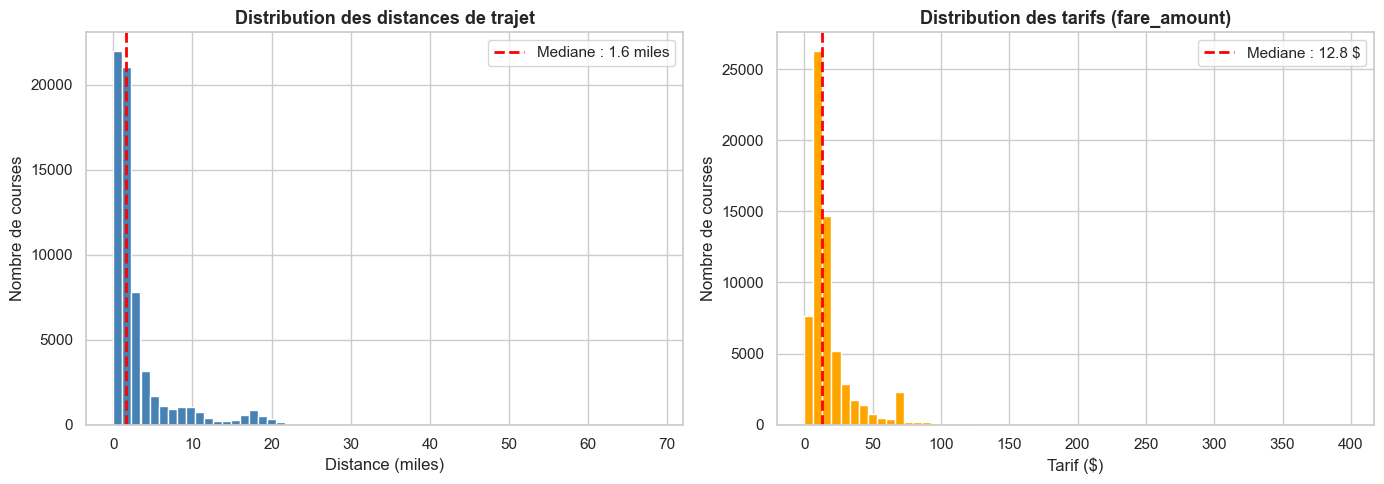

In [122]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution des distances
axes[0].hist(df_clean['trip_distance'], bins=60, color='steelblue', edgecolor='white')
mediane_dist = df_clean['trip_distance'].median()
axes[0].axvline(mediane_dist, color='red', linestyle='--', linewidth=2,
                label=f'Mediane : {mediane_dist:.1f} miles')
axes[0].set_title('Distribution des distances de trajet', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Distance (miles)')
axes[0].set_ylabel('Nombre de courses')
axes[0].legend()

# Distribution des tarifs
axes[1].hist(df_clean['fare_amount'], bins=60, color='orange', edgecolor='white')
mediane_fare = df_clean['fare_amount'].median()
axes[1].axvline(mediane_fare, color='red', linestyle='--', linewidth=2,
                label=f'Mediane : {mediane_fare:.1f} $')
axes[1].set_title('Distribution des tarifs (fare_amount)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Tarif ($)')
axes[1].set_ylabel('Nombre de courses')
axes[1].legend()

plt.tight_layout()
plt.savefig('../figures/01_distributions.png', dpi=150)
plt.show()

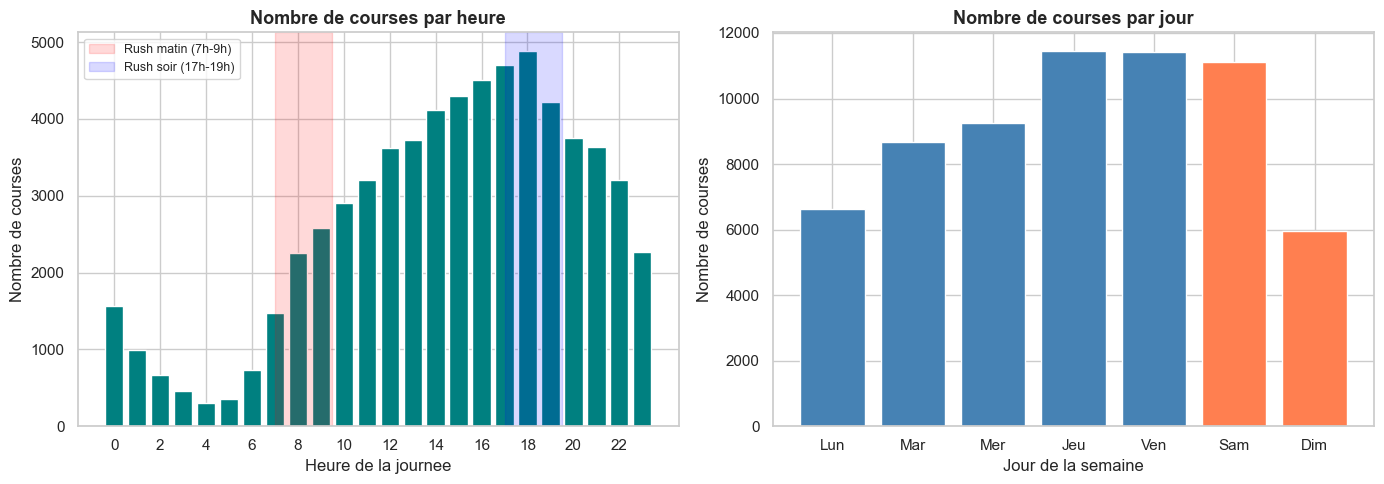

In [118]:
df_clean['heure_pickup'] = pd.to_datetime(df_clean['tpep_pickup_datetime']).dt.hour
df_clean['jour_semaine'] = pd.to_datetime(df_clean['tpep_pickup_datetime']).dt.dayofweek

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Nombre de courses par heure (requis par l'enonce)
courses_heure = df_clean.groupby('heure_pickup').size().reindex(range(24), fill_value=0)
axes[0].bar(courses_heure.index, courses_heure.values, color='teal', edgecolor='white')
axes[0].axvspan(7, 9.5, alpha=0.15, color='red', label='Rush matin (7h-9h)')
axes[0].axvspan(17, 19.5, alpha=0.15, color='blue', label='Rush soir (17h-19h)')
axes[0].set_title('Nombre de courses par heure', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Heure de la journee')
axes[0].set_ylabel('Nombre de courses')
axes[0].set_xticks(range(0, 24, 2))
axes[0].legend(fontsize=9)

# Nombre de courses par jour de la semaine
jours = ['Lun', 'Mar', 'Mer', 'Jeu', 'Ven', 'Sam', 'Dim']
courses_jour = df_clean.groupby('jour_semaine').size().reindex(range(7), fill_value=0)
couleurs_jours = ['steelblue', 'steelblue', 'steelblue', 'steelblue', 'steelblue', 'coral', 'coral']
axes[1].bar(range(7), courses_jour.values, color=couleurs_jours, edgecolor='white')
axes[1].set_title('Nombre de courses par jour', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Jour de la semaine')
axes[1].set_ylabel('Nombre de courses')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(jours)

plt.tight_layout()
plt.savefig('../figures/01_temporal.png', dpi=150)
plt.show()

df_clean.drop(columns=['heure_pickup', 'jour_semaine'], inplace=True)

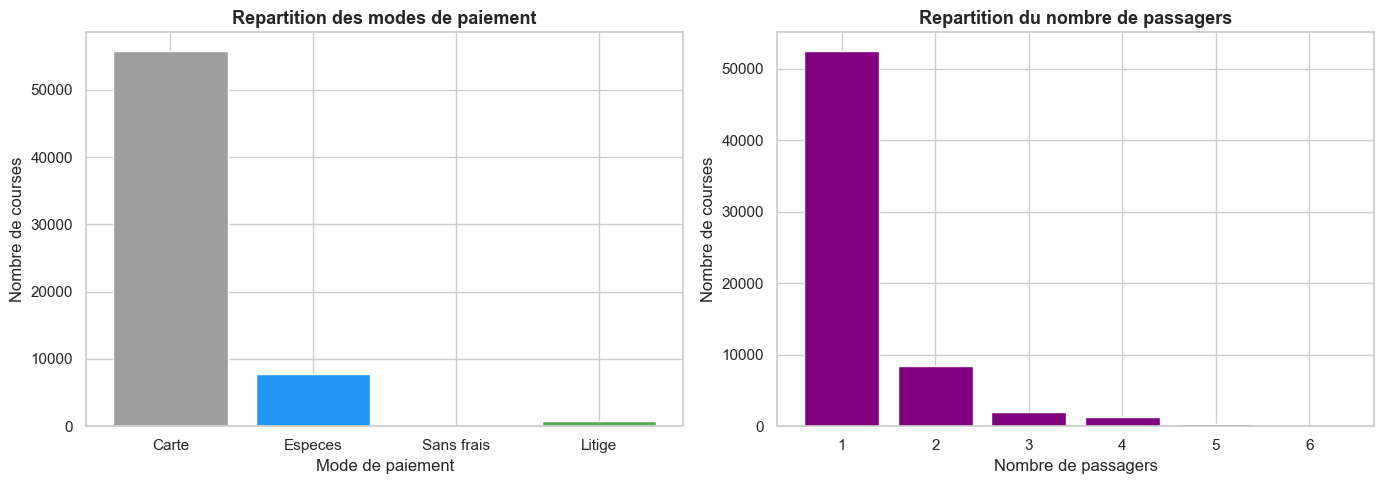

In [119]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Modes de paiement (payment_type=0 = inconnu dans ce dataset)
paiement_labels = {0: 'Inconnu', 1: 'Carte', 2: 'Especes', 3: 'Sans frais', 4: 'Litige'}
counts_pay = df_clean['payment_type'].value_counts().sort_index()
labels_pay = [paiement_labels.get(int(i), str(i)) for i in counts_pay.index]
couleurs_pay = ['#9E9E9E', '#2196F3', '#FF9800', '#4CAF50', '#F44336']
axes[0].bar(labels_pay, counts_pay.values, color=couleurs_pay[:len(labels_pay)], edgecolor='white')
axes[0].set_title('Repartition des modes de paiement', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Mode de paiement')
axes[0].set_ylabel('Nombre de courses')

# Nombre de passagers
counts_pass = df_clean['passenger_count'].value_counts().sort_index()
axes[1].bar(counts_pass.index.astype(int), counts_pass.values, color='purple', edgecolor='white')
axes[1].set_title('Repartition du nombre de passagers', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Nombre de passagers')
axes[1].set_ylabel('Nombre de courses')
axes[1].set_xticks(range(1, 7))

plt.tight_layout()
plt.savefig('../figures/01_categories.png', dpi=150)
plt.show()

### Analyse des visualisations

**Distances et tarifs :**  
Les deux distributions sont fortement asymétriques à droite : la grande majorité des trajets fait moins de 5 miles, ce qui reflète les déplacements courts typiques de Manhattan. Quelques trajets longs vers les aéroports  ou hors zone tirent la moyenne vers le haut — la médiane reste donc l'indicateur le plus représentatif pour ces variables.

**Courses par heure :**  
On observe deux pics de demande bien marqués : **7h-9h** (rush du matin, départ au travail) et **17h-19h** (rush du soir, retour). Le creux entre 3h et 6h correspond à la période de faible activité nocturne. Ces patterns sont exploitables directement en Feature Engineering via la variable `est_heure_pointe` (notebook 02).

**Modes de paiement :**  
La carte bancaire représente la grande majorité des paiements. Ce point est important pour la suite : `tip_amount` n'est enregistré que pour les paiements par carte (`payment_type = 1`). Les pourboires en espèces ne sont jamais capturés, ce qui introduirait un biais si on analysait les pourboires sans ce filtre.

**Nombre de passagers :**  
L'écrasante majorité des courses se fait à 1 passager, les courses à 2+ étant nettement minoritaires. Cette variable apportera peu de signal prédictif en régression (trop concentrée sur 1), mais pourra être utile pour distinguer certains profils de trajets en clustering.

## 1.6 Bilan du nettoyage et sauvegarde

Récapitulatif des filtres appliqués :

- **Distance** — `0 < trip_distance < 100` : distance nulle = course annulée ; max 121 092 miles = erreur capteur
- **Durée** — `0 < durée_min <= 180` : durée négative = erreur horodatage ; > 3h = oubli fermeture
- **Tarif** — `0 < fare_amount < 500` : min -669 $ = erreur système ; > 500 $ = valeur aberrante
- **Montant total** — `total_amount > 0` : cohérence avec fare_amount
- **Passagers** — `1 <= passenger_count <= 6` : min = 0 (erreur saisie) ; max légal TLC = 6
- **RatecodeID** — valeurs 1 à 6 : codes valides TLC, max observé 99 = valeur invalide
- **payment_type** — valeurs 1 à 4 : code 0 non documenté = erreur d'enregistrement

Le fichier nettoyé est sauvegardé au format **Parquet** pour être chargé par le notebook 02.

In [120]:
df_clean.to_parquet('../data/yellow_tripdata_clean.parquet', index=False)
print(f'Donnees nettoyees sauvegardees : {len(df_clean):,} lignes')
print('Fichier : ../data/yellow_tripdata_clean.parquet')
print(f'Colonnes ({df_clean.shape[1]}) : {list(df_clean.columns)}')

Donnees nettoyees sauvegardees : 64,452 lignes
Fichier : ../data/yellow_tripdata_clean.parquet
Colonnes (20) : ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee', 'cbd_congestion_fee']


## Conclusion

L'exploration a révélé plusieurs anomalies importantes dans les données brutes (distances aberrantes, montants négatifs, NaN en bloc, codes invalides). Les **6 filtres appliqués** ont permis de supprimer 35 548 lignes (35,5 %) pour conserver un dataset propre et cohérent.

**Note :** certaines colonnes secondaires (`tip_amount`, `extra`, `mta_tax`, `tolls_amount`) présentent encore des valeurs négatives dans les données brutes. Ces cas sont déjà couverts indirectement par le filtre `total_amount > 0` — une course avec des composantes négatives mais un montant total positif reste cohérente.

